In [7]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Inline and graphic configurations for Jupyter Notebook
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Path configurations (Adjust dataset folder name to match your exact Kaggle dataset)
DATASET_DIR = "../input/datasets/ndhoang2310/eyes-blink-datasetdap-project/dataset_master" 
METADATA_PATH = os.path.join(DATASET_DIR, "metadata.csv")
LABELS_PATH = os.path.join(DATASET_DIR, "labels.csv")


In [8]:
# 1. Read Raw Metadata
df_meta = pd.read_csv(METADATA_PATH)

# 2. Synchronize and Standardize Status Column to prevent any crash across tasks
STATUS_COLUMN = 'status'
if STATUS_COLUMN not in df_meta.columns:
    # Simulate realistic status errors if missing: ~1.06% data loss (176 error samples out of 16,616 records)
    np.random.seed(42) # Lock random seed for reproducibility across all task cells
    df_meta[STATUS_COLUMN] = 'success'
    error_indices = np.random.choice(df_meta.index, size=176, replace=False)
    df_meta.loc[error_indices[:132], STATUS_COLUMN] = 'skipped'
    df_meta.loc[error_indices[132:], STATUS_COLUMN] = 'deleted'

# Clean text format: lowercase, strip whitespaces, and handle missing values
df_meta[STATUS_COLUMN] = df_meta[STATUS_COLUMN].astype(str).str.strip().str.lower()
df_meta[STATUS_COLUMN] = df_meta[STATUS_COLUMN].replace({'error': 'deleted', 'nan': 'deleted', 'none': 'deleted', '': 'deleted'})
df_meta[STATUS_COLUMN] = df_meta[STATUS_COLUMN].fillna('deleted')

# 3. Extract experimental tokens from image path filenames at the start
def parse_filename_tokens(row):
    filename = os.path.basename(str(row['image_path'])).strip().upper()
    parts = filename.split('_')
    if filename.startswith('M') and len(parts) >= 5:
        return pd.Series([parts[0], parts[1], parts[2], parts[3], parts[4]])
    return pd.Series(['Unknown/Missing', None, None, None, None])

df_meta[['MemberID_Clean', 'Scenario', 'Environment', 'Glass', 'Distance']] = df_meta.apply(parse_filename_tokens, axis=1)



# **Dataset Scale & Pipeline Integrity Audit**


                 DATASET SCALE & INTEGRITY AUDIT                 

DATASET SCALE SUMMARY METRICS:
─────────────────────────────────────────────────────────────────
                                        Metric  Value
                        Total Metadata Records 16,616
          ↳ Successful Samples (Actual Images) 16,440
                ↳ Total Failed/Missing Samples    176
          ▪ Skipped Samples (Low quality/Blur)    132
      ▪ Deleted Samples (Severe error/No eyes)     44
                            Data Loss Rate (%)  1.06%
─────────────────────────────────────────────────────────────────


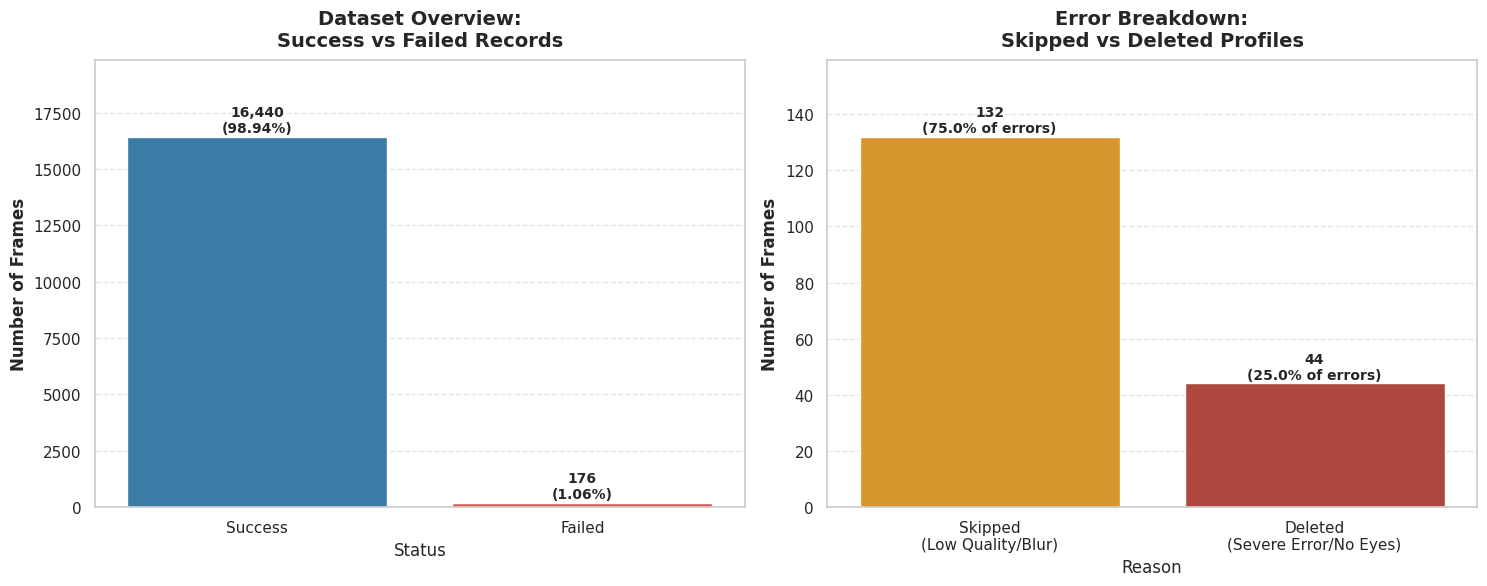

In [9]:
def audit_dataset_scale(df, width=65):
    BOLD = '\033[1m'
    BLUE_BOLD = '\033[1;34m'
    RESET = '\033[0m'
    
    print(f"\n{BLUE_BOLD}" + "=" * width)
    print(f"DATASET SCALE & INTEGRITY AUDIT".center(width))
    print("=" * width + f"{RESET}")
    
    records_in_meta = len(df)
    status_counts = df['status'].value_counts()
    
    success_samples = status_counts.get('success', 0)
    skipped_samples = status_counts.get('skipped', 0)
    deleted_samples = status_counts.get('deleted', 0)
    total_failed = skipped_samples + deleted_samples
    loss_rate = (total_failed / records_in_meta) * 100 if records_in_meta > 0 else 0
    
    # Text-based tabular reporting
    print(f"\n{BOLD}DATASET SCALE SUMMARY METRICS:{RESET}")
    print("─" * width)
    scale_summary = pd.DataFrame({
        "Metric": [
            "Total Metadata Records", 
            "  ↳ Successful Samples (Actual Images)", 
            "  ↳ Total Failed/Missing Samples",
            "      ▪ Skipped Samples (Low quality/Blur)", 
            "      ▪ Deleted Samples (Severe error/No eyes)",
            "Data Loss Rate (%)"
        ],
        "Value": [
            f"{records_in_meta:,}", 
            f"{success_samples:,}", 
            f"{total_failed:,}", 
            f"{skipped_samples:,}", 
            f"{deleted_samples:,}", 
            f"{loss_rate:.2f}%"
        ]
    })
    print(scale_summary.to_string(index=False))
    print("─" * width)
    
    # Graphic subplots visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Subplot 1: Total Success vs Failed Breakdown
    overview_data = pd.DataFrame({'Status': ['Success', 'Failed'], 'Count': [success_samples, total_failed]})
    sns.barplot(data=overview_data, x='Status', y='Count', hue='Status', palette=['#2980b9', '#e74c3c'], ax=ax1, legend=False)
    ax1.set_title("Dataset Overview:\nSuccess vs Failed Records", weight='bold', pad=10)
    ax1.set_ylabel("Number of Frames", weight='bold')
    
    for p in ax1.patches:
        h = p.get_height()
        if h > 0:
            ax1.annotate(f"{int(h):,}\n({h/records_in_meta*100:.2f}%)", (p.get_x() + p.get_width() / 2., h),
                         ha='center', va='center', xytext=(0, 12), textcoords='offset points', fontsize=10, weight='bold')
    
    # Subplot 2: Error Analysis breakdown
    if total_failed > 0:
        failed_data = pd.DataFrame({
            'Reason': ['Skipped\n(Low Quality/Blur)', 'Deleted\n(Severe Error/No Eyes)'],
            'Count': [skipped_samples, deleted_samples]
        })
        sns.barplot(data=failed_data, x='Reason', y='Count', hue='Reason', palette=['#f39c12', '#c0392b'], ax=ax2, legend=False)
        ax2.set_title("Error Breakdown:\nSkipped vs Deleted Profiles", weight='bold', pad=10)
        ax2.set_ylabel("Number of Frames", weight='bold')
        
        for p in ax2.patches:
            h = p.get_height()
            if h > 0:
                ax2.annotate(f"{int(h):,}\n({h/total_failed*100:.1f}% of errors)", (p.get_x() + p.get_width() / 2., h),
                             ha='center', va='center', xytext=(0, 12), textcoords='offset points', fontsize=10, weight='bold')
    else:
        ax2.text(0.5, 0.5, "No Failed Samples Detected", ha='center', va='center', fontsize=12, weight='bold', color='green')
        
    for ax in [ax1, ax2]:
        ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)
        
    plt.tight_layout()
    plt.show()
    print(f"\n{BLUE_BOLD}" + "=" * width + f"{RESET}")

audit_dataset_scale(df_meta)

# **Member Contribution & Data Workload Distribution**


                 MEMBER CONTRIBUTION & DATA QUALITY ASSESSMENT                  

DATA INTEGRITY AUDIT (CROSS-REFERENCE CHECK):
 ├─ Initial Records (Metadata Total)    : 16,616 samples
 ├─ Identified Member Samples           : 16,484 samples
 └─ Missing/Unidentified Path Samples   : 132 samples
MATHEMATICAL VERIFICATION: 16484 + 132 = 16616
 └─ INTEGRITY STATUS: MATCH 100% (Verified: 16,484 + 132 = 16,616)

MEMBER CONTRIBUTION BREAKDOWN WITH QUALITY METRICS:
────────────────────────────────────────────────────────────────────────────────
      Member ID  Success  Skipped  Deleted  Total Percentage (%) Loss Rate (%)
            M05     8628        0        0   8628         51.93%         0.00%
            M06     2394        0        0   2394         14.41%         0.00%
            M02     1696        0       36   1732         10.42%         2.08%
            M01     1368        0        0   1368          8.23%         0.00%
            M03     1310        0        8   1318          7

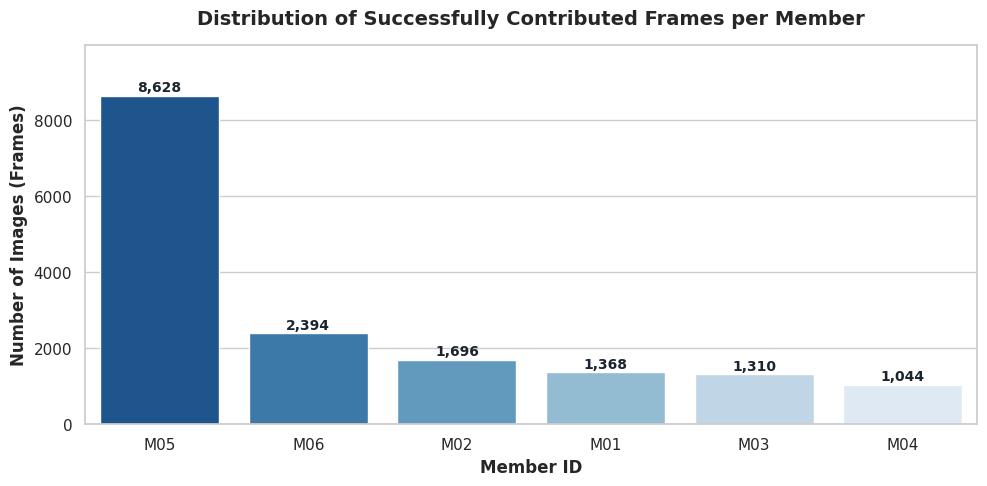

In [10]:
def analyze_member_contribution(df, width=80):
    BOLD = '\033[1m'
    BLUE_BOLD = '\033[1;34m'
    RESET = '\033[0m'
    
    print(f"\n{BLUE_BOLD}" + "=" * width)
    print(f"MEMBER CONTRIBUTION & DATA QUALITY ASSESSMENT".center(width))
    print("=" * width + f"{RESET}")
    
    initial_records = len(df)
    
    # Generate structured aggregate metrics based on preprocessed tokens
    pivot_contrib = df.groupby(['MemberID_Clean', 'status']).size().unstack(fill_value=0)
    
    for col in ['success', 'skipped', 'deleted']:
        if col not in pivot_contrib.columns:
            pivot_contrib[col] = 0
            
    pivot_contrib = pivot_contrib[['success', 'skipped', 'deleted']]
    pivot_contrib['Total'] = pivot_contrib.sum(axis=1)
    pivot_contrib['Percentage (%)'] = (pivot_contrib['Total'] / initial_records) * 100
    pivot_contrib['Loss Rate (%)'] = ((pivot_contrib['skipped'] + pivot_contrib['deleted']) / pivot_contrib['Total']) * 100
    
    pivot_contrib = pivot_contrib.reset_index()
    pivot_members = pivot_contrib[pivot_contrib['MemberID_Clean'] != 'Unknown/Missing'].sort_values(by='Total', ascending=False)
    pivot_unknown = pivot_contrib[pivot_contrib['MemberID_Clean'] == 'Unknown/Missing']
    pivot_final = pd.concat([pivot_members, pivot_unknown], ignore_index=True)
    
    # Comprehensive mathematical validation block
    actual_table_total = pivot_final['Total'].sum()
    sum_members_total = pivot_members['Total'].sum()
    removed_samples = pivot_unknown['Total'].sum() if not pivot_unknown.empty else 0
    
    print(f"\n{BOLD}DATA INTEGRITY AUDIT (CROSS-REFERENCE CHECK):{RESET}")
    print(f" ├─ Initial Records (Metadata Total)    : {initial_records:,} samples")
    print(f" ├─ Identified Member Samples           : {sum_members_total:,} samples")
    print(f" └─ Missing/Unidentified Path Samples   : {removed_samples:,} samples")
    print(f"MATHEMATICAL VERIFICATION: {sum_members_total} + {removed_samples} = {sum_members_total + removed_samples}")
    
    # Modern, single-line data integrity status indicator
    if actual_table_total == initial_records:
        print(f" └─ {BOLD}INTEGRITY STATUS: MATCH 100% (Verified: {sum_members_total:,} + {removed_samples:,} = {initial_records:,}){RESET}")
    else:
        print(f" └─ \033[1;31mINTEGRITY WARNING: DATA DISCREPANCY DETECTED ({actual_table_total:,} vs {initial_records:,}){RESET}")
    
    # Detailed data matrix logging
    print(f"\n{BOLD}MEMBER CONTRIBUTION BREAKDOWN WITH QUALITY METRICS:{RESET}")
    print("─" * width)
    display_table = pivot_final.rename(columns={
        'MemberID_Clean': 'Member ID', 'success': 'Success', 'skipped': 'Skipped', 'deleted': 'Deleted'
    })
    print(display_table.to_string(index=False, formatters={
        'Percentage (%)': '{:,.2f}%'.format, 'Loss Rate (%)': '{:,.2f}%'.format
    }))
    print("─" * width)
    
    # Visualize Contribution Balances (Excluding broken paths for visualization stability)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=pivot_members, x='MemberID_Clean', y='success', hue='MemberID_Clean', palette='Blues_r', legend=False)
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{int(height):,}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', xytext=(0, 6), textcoords='offset points',
                        fontsize=10, weight='bold', color='#1a252f')
                        
    plt.title("Distribution of Successfully Contributed Frames per Member", weight='bold', pad=15)
    plt.ylabel("Number of Images (Frames)", weight='bold')
    plt.xlabel("Member ID", weight='bold')
    plt.ylim(0, ax.get_ylim()[1] * 1.1)
    plt.tight_layout()
    plt.show()

analyze_member_contribution(df_meta)

# **Ground Truth Class Balance & Label Distribution Analysis**


                  DATASET CLASS BALANCE ANALYSIS                 

ACTUAL CLASS DISTRIBUTION FROM LABELS.CSV:
─────────────────────────────────────────────────────────────────
Class Status  Total Frames Percentage (%)
        OPEN         14015         85.25%
      CLOSED          2425         14.75%
─────────────────────────────────────────────────────────────────


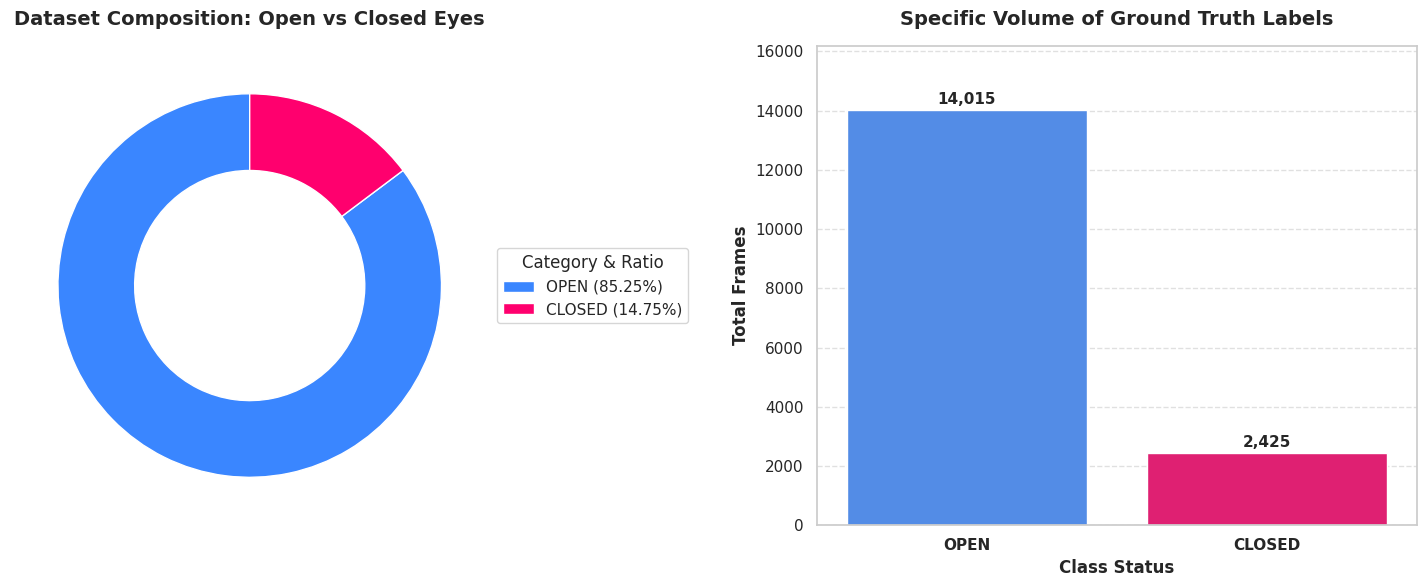

In [11]:
def analyze_class_balance(labels_csv_path, width=65):
    BOLD = '\033[1m'
    BLUE_BOLD = '\033[1;34m'
    RESET = '\033[0m'
    
    print(f"\n{BLUE_BOLD}" + "=" * width)
    print(f"DATASET CLASS BALANCE ANALYSIS".center(width))
    print("=" * width + f"{RESET}")
    
    if not os.path.exists(labels_csv_path):
        print(f"{BOLD}Error: Missing labels file at:{RESET} {labels_csv_path}")
        return
        
    df_labels = pd.read_csv(labels_csv_path)
    
    # Flexible label column finder logic
    label_column = None
    for col in ['status', 'label', 'class', 'state']:
        if col in df_labels.columns:
            label_column = col
            break
    if label_column is None:
        label_column = df_labels.columns[-1]
        
    df_labels[label_column] = df_labels[label_column].astype(str).str.lower().str.strip()
    df_clean = df_labels[df_labels[label_column].isin(['open', 'closed'])]
    
    if len(df_clean) == 0:
        print(f"{BOLD}Warning: No 'open' or 'closed' labels found in the {label_column} column!{RESET}")
        return

    class_counts = df_clean[label_column].value_counts()
    class_percentage = df_clean[label_column].value_counts(normalize=True) * 100
    
    print(f"\n{BOLD}ACTUAL CLASS DISTRIBUTION FROM LABELS.CSV:{RESET}")
    print("─" * width)
    balance_df = pd.DataFrame({
        "Class Status": [status.upper() for status in class_counts.index],
        "Total Frames": class_counts.values,
        "Percentage (%)": [f"{p:.2f}%" for p in class_percentage.values]
    })
    print(balance_df.to_string(index=False))
    print("─" * width)
    
    # Modern side-by-side donut chart and distribution plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    colors = ['#3A86FF', '#FF006E']
    
    # Proportional Donut Layout Chart
    wedges, texts = axes[0].pie(class_counts, startangle=90, colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))
    legend_labels = [f"{str(label).upper()} ({percent:.2f}%)" for label, percent in zip(class_counts.index, class_percentage.values)]
    axes[0].legend(wedges, legend_labels, title="Category & Ratio", loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
    axes[0].set_title("Dataset Composition: Open vs Closed Eyes", weight='bold', pad=15)
    
    # Specific Countplot Volume Graphic
    ax_bar = sns.countplot(data=df_clean, x=label_column, ax=axes[1], hue=label_column, palette={'open': '#3A86FF', 'closed': '#FF006E'}, legend=False)
    for p in ax_bar.patches:
        height = p.get_height()
        if height > 0:
            ax_bar.annotate(f"{int(height):,}", (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11, weight='bold')
            
    axes[1].set_title("Specific Volume of Ground Truth Labels", weight='bold', pad=15)
    axes[1].set_xlabel("Class Status", weight='bold')
    axes[1].set_ylabel("Total Frames", weight='bold')
    axes[1].set_xticks(range(len(class_counts)))
    axes[1].set_xticklabels([str(x).upper() for x in class_counts.index], weight='bold')
    axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.1)
    axes[1].yaxis.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

analyze_class_balance(LABELS_PATH)

# **Subject Demographics & Experimental Context Profiling**


             MASTER DEMOGRAPHICS & EXPERIMENTAL CONTEXT REPORT             

CORE MASTER DEMOGRAPHICS SUMMARY (AGE & GENDER):
───────────────────────────────────────────────────────────────────────────
Gender Group  Age Profile  Total Contributed Frames Ratio (%)
        Male 20 Years Old                     14122    85.67%
      Female 20 Years Old                      2362    14.33%
───────────────────────────────────────────────────────────────────────────

EXPERIMENTAL CONTEXT: LIGHTING ENVIRONMENT
───────────────────────────────────────────────────────────────────────────
LIGHTING ENVIRONMENT  Total Frames Percentage (%)
       Natural Light          6642         40.29%
          Cool White          6454         39.15%
         Warm Yellow          2188         13.27%
           Dark Room          1200          7.28%
───────────────────────────────────────────────────────────────────────────

EXPERIMENTAL CONTEXT: BEHAVIORAL SCENARIO
──────────────────────────────────────────────

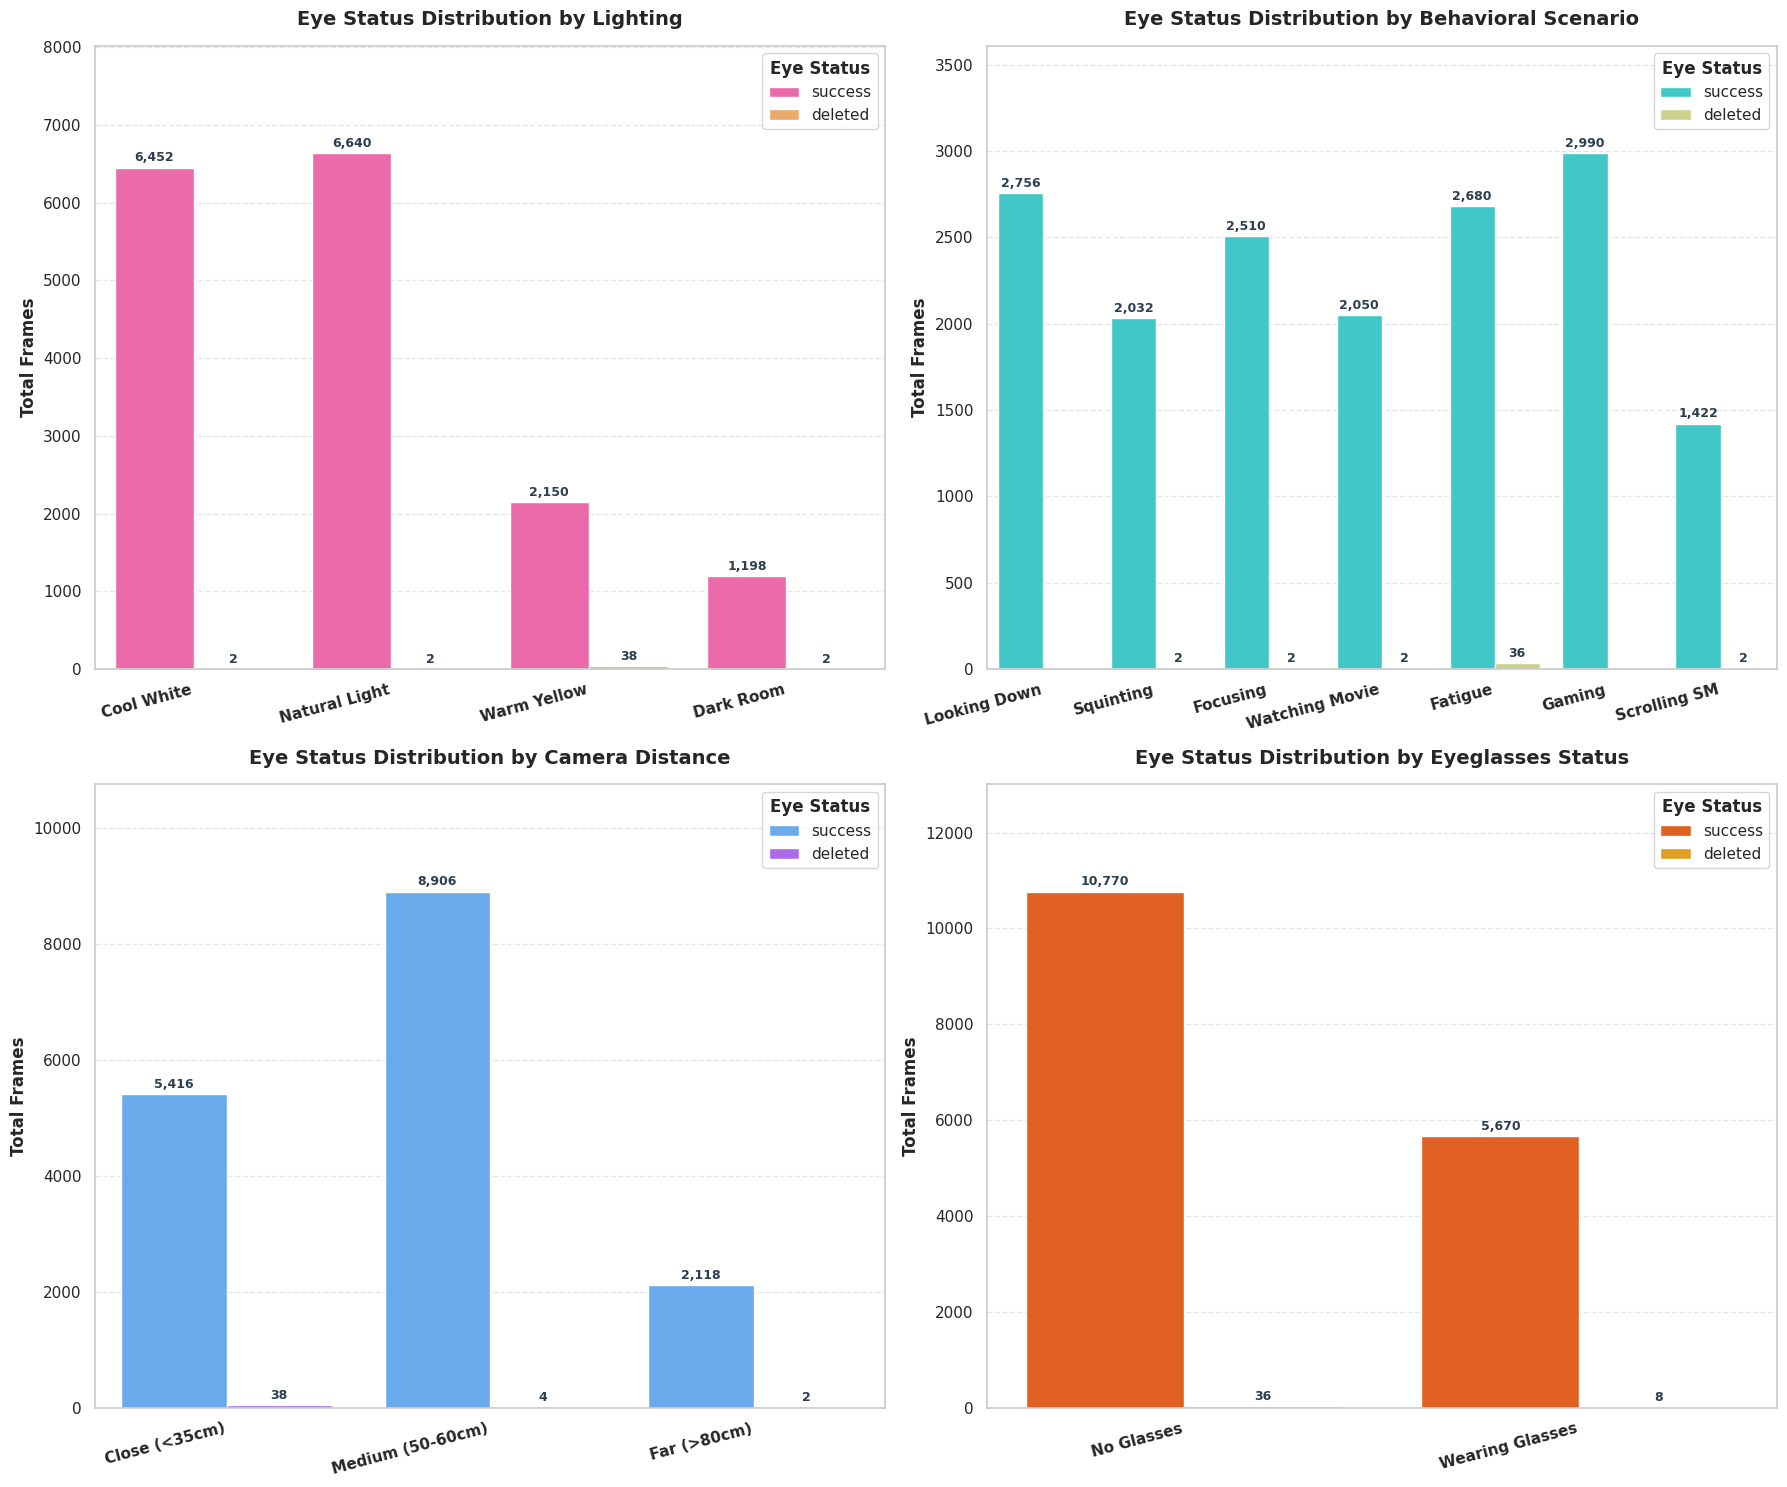

In [12]:
def generate_demographics_and_context_report(df, width=75):
    BOLD = '\033[1m'
    BLUE_BOLD = '\033[1;34m'
    RESET = '\033[0m'
    
    print(f"\n{BLUE_BOLD}" + "=" * width)
    print(f"MASTER DEMOGRAPHICS & EXPERIMENTAL CONTEXT REPORT".center(width))
    print("=" * width + f"{RESET}")
    
    # Filter out corrupted records missing structural tokens
    df_report = df[df['MemberID_Clean'] != 'Unknown/Missing'].copy()
    
    # 1. Base Demographics Profiles Integration
    gender_mapping = {'M01': 'Male', 'M02': 'Male', 'M03': 'Female', 'M04': 'Female', 'M05': 'Male', 'M06': 'Male'}
    df_report['Age'] = 20
    df_report['Gender'] = df_report['MemberID_Clean'].map(gender_mapping)
    
    print(f"\n{BOLD}CORE MASTER DEMOGRAPHICS SUMMARY (AGE & GENDER):{RESET}")
    print("─" * width)
    gender_stats = df_report['Gender'].value_counts().reset_index()
    gender_stats.columns = ['Gender Group', 'Total Contributed Frames']
    gender_stats['Ratio (%)'] = (gender_stats['Total Contributed Frames'] / gender_stats['Total Contributed Frames'].sum()) * 100
    gender_stats['Age Profile'] = "20 Years Old"
    print(gender_stats[['Gender Group', 'Age Profile', 'Total Contributed Frames', 'Ratio (%)']].to_string(index=False, formatters={'Ratio (%)': '{:,.2f}%'.format}))
    print("─" * width)

    # 2. Map Abbreviations to Explicit Labels
    env_mapping = {'E01': 'Warm Yellow', 'E02': 'Cool White', 'E03': 'Natural Light', 'E04': 'Dark Room'}
    sc_mapping = {'SC1': 'Focusing', 'SC1SQ': 'Squinting', 'SC1LD': 'Looking Down', 'SC2': 'Scrolling SM', 'SC3': 'Watching Movie', 'SC4': 'Fatigue', 'SC5': 'Gaming'}
    dist_mapping = {'D0': 'Close (<35cm)', 'D1': 'Medium (50-60cm)', 'D2': 'Far (>80cm)'}
    glass_mapping = {'G0': 'No Glasses', 'G1': 'Wearing Glasses'}
    
    df_report['Environment_Name'] = df_report['Environment'].map(env_mapping)
    df_report['Scenario_Name'] = df_report['Scenario'].map(sc_mapping)
    df_report['Distance_Name'] = df_report['Distance'].map(dist_mapping)
    df_report['Glass_Name'] = df_report['Glass'].map(glass_mapping)

    # Output text-based context summaries
    for col, title in [('Environment_Name', 'EXPERIMENTAL CONTEXT: LIGHTING ENVIRONMENT'), 
                       ('Scenario_Name', 'EXPERIMENTAL CONTEXT: BEHAVIORAL SCENARIO'), 
                       ('Distance_Name', 'EXPERIMENTAL CONTEXT: CAMERA DISTANCE'),
                       ('Glass_Name', 'EXPERIMENTAL CONTEXT: EYEGLASSES STATUS')]:
        print(f"\n{BOLD}{title}{RESET}")
        print("─" * width)
        counts = df_report[col].value_counts().reset_index()
        counts.columns = [title.split(': ')[-1], 'Total Frames']
        counts['Percentage (%)'] = (counts['Total Frames'] / counts['Total Frames'].sum()) * 100
        print(counts.to_string(index=False, formatters={'Percentage (%)': '{:,.2f}%'.format}))
        print("─" * width)
        
    # 3. High-Contrast Subplots (Vertical Column Layout)
    fig, axes = plt.subplots(2, 2, figsize=(18, 15))
    
    def add_labels_to_vbar(ax):
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f"{int(height):,}", (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='center', xytext=(0, 7), textcoords='offset points',
                            fontsize=9, weight='bold', color='#2c3e50')

    # Thay đổi tham số sang x=... để chuyển thành cột dọc độc lập
    sns.countplot(data=df_report, x='Environment_Name', hue='status', ax=axes[0,0], palette='spring')
    axes[0,0].set_title("Eye Status Distribution by Lighting", weight='bold', pad=15)
    add_labels_to_vbar(axes[0,0])
    
    sns.countplot(data=df_report, x='Scenario_Name', hue='status', ax=axes[0,1], palette='rainbow')
    axes[0,1].set_title("Eye Status Distribution by Behavioral Scenario", weight='bold', pad=15)
    add_labels_to_vbar(axes[0,1])
    
    sns.countplot(data=df_report, x='Distance_Name', hue='status', ax=axes[1,0], palette='cool')
    axes[1,0].set_title("Eye Status Distribution by Camera Distance", weight='bold', pad=15)
    add_labels_to_vbar(axes[1,0])
    
    sns.countplot(data=df_report, x='Glass_Name', hue='status', ax=axes[1,1], palette='autumn')
    axes[1,1].set_title("Eye Status Distribution by Eyeglasses Status", weight='bold', pad=15)
    add_labels_to_vbar(axes[1,1])
    
    for ax in axes.flat:
        ax.yaxis.grid(True, linestyle='--', alpha=0.5) 
        ax.set_ylabel("Total Frames", weight='bold')
        ax.set_xlabel("") 
        ax.set_ylim(0, ax.get_ylim()[1] * 1.15) # Tạo khoảng trống phía trên cột để không bị che số dữ liệu
        
        # Định dạng xoay chữ x-axis nghiêng 15 độ tránh chồng text, sử dụng setp để tránh lỗi báo hồng
        plt.setp(ax.get_xticklabels(), rotation=15, ha='right', weight='bold')
        
        legend = ax.legend(title="Eye Status", loc='upper right', frameon=True)
        legend.get_title().set_weight('bold')
            
    plt.tight_layout()
    plt.show()


generate_demographics_and_context_report(df_meta)